In [1]:
import numpy as np
import matplotlib.pyplot as plt

Nind = 5
Lind = 20
Pc = 0.70
Pm = 1/15
Maxgen = 100
Nvar = 1
rango = np.array([[0.0, 0.875]])

In [2]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

In [3]:
def decodifica(genotipo, rango):
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape

    bits_por_var = np.full(Nvar, Lind // Nvar, dtype=int)
    bits_por_var[: Lind % Nvar] += 1

    fenotipo = np.zeros((Nind, Nvar))
    inicio = 0

    for j, Lvar in enumerate(bits_por_var):
        fin = inicio + Lvar
        subcadena = genotipo[:, inicio:fin]
        potencias = 2 ** np.arange(Lvar - 1, -1, -1)
        decimal = subcadena @ potencias
        li, ls = rango[j]
        fenotipo[:, j] = li + ((ls - li) / (2 ** Lvar - 1)) * decimal
        inicio = fin

    return fenotipo

In [4]:
def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))

    for i in range(Nind):
        x = fenotipo[i, 0]
        objv[i, 0] = (1 - (((11 / 2) * x) - (7 / 2)) ** 2) * (np.cos(((11 / 2) * x) - (7 / 2)) + 1) + 2

    return objv

In [5]:
def rankeo(objv, direccion):
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        posori = np.argsort(objv[:, 0])
    else:
        posori = np.argsort(-objv[:, 0])

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    aptitud[posori, 0] = apt

    return aptitud

In [6]:
def ruleta(genotipo, fenotipo, aptitud):
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux[0]

    nuevo_gen = genotipo[idx.flatten(), :]

    return nuevo_gen

In [7]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    return aux_gen

In [8]:
def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    mascara = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, mascara).astype(int)

    return nuevo_gen

In [9]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)

In [10]:
Mejor = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind), dtype=int)  
objv = objfun(fenotipo)  

idx0 = np.argmax(objv)
Mejor[0] = objv[idx0]
Mejor_cromosoma[0, :] = genotipo[idx0, :]

In [11]:
generaciones = 5

while generaciones < Maxgen:  # Número de generaciones predefinidas
    aptitud = rankeo(objv, 1)  # cada generación se establece el fitness para cada solución encontrada
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)

    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    genotipo = nuevo_gen
    fenotipo = nuevo_feno
    objv = nuevo_objv

    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

In [12]:
idx_mejor = np.nanargmax(Mejor[:, 0])
mejor_valor = float(Mejor[idx_mejor, 0])
mejor_cromosoma = Mejor_cromosoma[idx_mejor, :].astype(int)
mejor_fenotipo = decodifica(mejor_cromosoma.reshape(1, -1), rango)[0]

print(f'Mejor generación: {idx_mejor}')
print(f'Mejor valor encontrado: {mejor_valor:.6f}')
print(f'Mejor cromosoma: {mejor_cromosoma}')
print(f'Mejor solución (x): {mejor_fenotipo[0]:.6f}')

Mejor generación: 65
Mejor valor encontrado: 4.000000
Mejor cromosoma: [1 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1]
Mejor solución (x): 0.636384


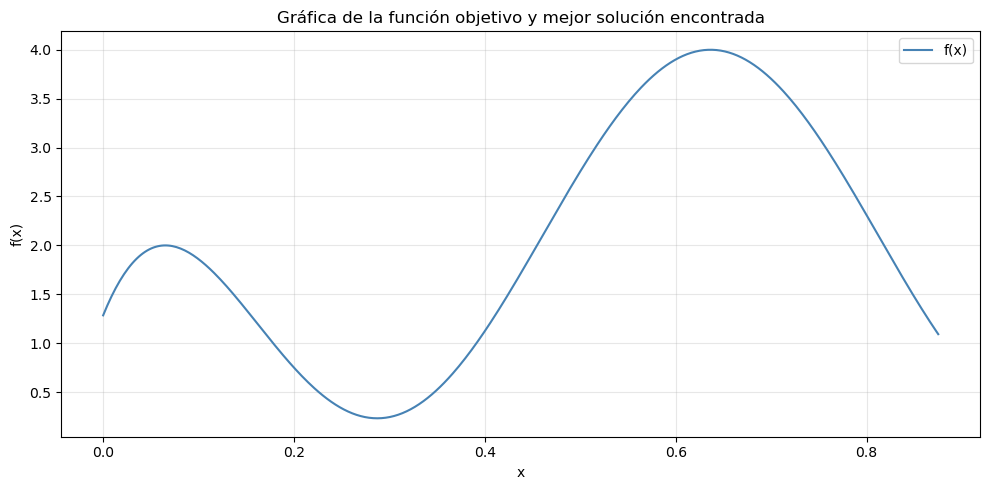

In [13]:
import matplotlib.pyplot as plt

x = np.linspace(rango[0, 0], rango[0, 1], 400)
feno_malla = x.reshape(-1, 1)
z = objfun(feno_malla).flatten()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, z, color='steelblue', label='f(x)')

# Usar la mejor solución global encontrada por el GA
x_mejor = mejor_fenotipo[0]
z_mejor = mejor_valor

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Gráfica de la función objetivo y mejor solución encontrada')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()